In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata

df = pd.read_csv("2004-2021.tsv", sep = "\t")

print("Ok!")

Ok!


In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df["data_inicial"] = pd.to_datetime(df["data_inicial"])

df["produto"] = df["produto"].apply(
    lambda x: unicodedata.normalize("NFKD", x).encode("ASCII", "ignore"). decode("utf-8"))

df["ano"] = df["data_inicial"].dt.year

# GASOLINA POR ESTADO

In [13]:
gasolina_estado = df[df["produto"] == "GASOLINA COMUM"]

media_estado = gasolina_estado.groupby("estado")["preço_médio_revenda"].mean().sort_values(ascending=False)

media_estado.head(10)

estado
ACRE                 3.574378
TOCANTINS            3.324233
RONDONIA             3.317381
MATO GROSSO          3.315802
RIO DE JANEIRO       3.307758
PARA                 3.291103
ALAGOAS              3.263207
RIO GRANDE DO SUL    3.217851
RORAIMA              3.215751
BAHIA                3.213920
Name: preço_médio_revenda, dtype: float64

# EVOLUÇÃO POR ESTADO

In [18]:
estado1 = "SAO PAULO"
estado2 = "BAHIA"
estado3 = "ACRE"

In [22]:
sp = gasolina_estado[gasolina_estado["estado"] == estado1].groupby("ano")["preço_médio_revenda"].mean()
ba = gasolina_estado[gasolina_estado["estado"] == estado2].groupby("ano")["preço_médio_revenda"].mean()
ac = gasolina_estado[gasolina_estado["estado"] == estado3].groupby("ano")["preço_médio_revenda"].mean()

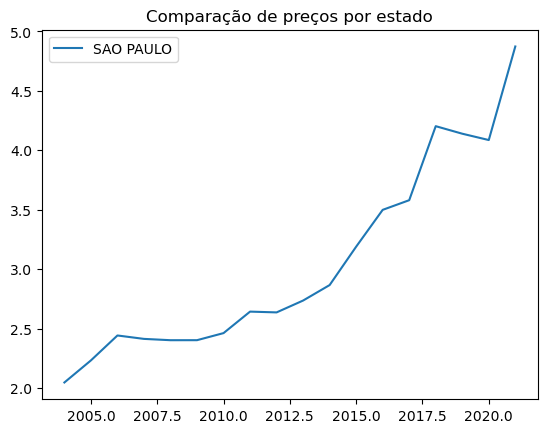

In [25]:
#Plot

plt.figure()

plt.plot(sp.index, sp.values, label = estado1)
#plt.plot(ba.index, ba.values, label = estado2)
#plt.plot(ac.index, ac.values, label = estado2)

plt.legend()
plt.title("Comparação de preços por estado")
plt.show()

# DISPERSÃO (VARIABILIDADE)

In [26]:
gasolina_estado.groupby("estado")["preço_médio_revenda"].std().sort_values(ascending=False).head(27)*100

estado
RIO DE JANEIRO         93.561713
MINAS GERAIS           87.343366
GOIAS                  83.814349
ACRE                   83.666057
RIO GRANDE DO NORTE    81.202584
PIAUI                  80.642299
CEARA                  80.573441
RIO GRANDE DO SUL      80.229608
BAHIA                  79.226621
SERGIPE                78.941065
TOCANTINS              78.899582
PARA                   76.662968
ALAGOAS                76.145778
AMAZONAS               75.991906
DISTRITO FEDERAL       75.544803
ESPIRITO SANTO         74.812708
PARAIBA                74.170565
RONDONIA               74.123840
PERNAMBUCO             73.909675
SAO PAULO              72.830937
PARANA                 72.694251
MARANHAO               69.873015
MATO GROSSO            68.463769
MATO GROSSO DO SUL     67.295820
SANTA CATARINA         67.136065
RORAIMA                65.579905
AMAPA                  57.944835
Name: preço_médio_revenda, dtype: float64

In [27]:
# Quais estados têm maior instabilidade de preços?

# Top 5
# RIO DE JANEIRO, MINAS GERAIS, GOIAS, ACRE, RIO GRANDE DO NORTE

# PERGUNTAS

In [ ]:
# 1. Sim, o Acre se mantem como o estado que tem a gasolina comum mais cara durante todos os anos.

# 2. Me ajude com esta pergunta.

# 3. RIO DE JANEIRO, MINAS GERAIS, GOIAS, ACRE, RIO GRANDE DO NORTE

# 4. Me ajude com esta pergunta.